### About data

As remote work continues to shape modern workplaces, understanding its effects on mental health, stress levels, and job satisfaction is crucial. This synthetic dataset is designed to simulate real-world trends and provide a structured foundation for analysis on how work location—remote, hybrid, and onsite—impacts employees across various industries.

With 5,000 AI-generated records, this dataset serves as a valuable resource for HR professionals, researchers, and data analysts looking to explore the relationship between work flexibility and employee well-being in a controlled, risk-free environment.

**Key Features:**

* Work Location Insights – Remote, Hybrid, and Onsite comparisons
* Stress & Mental Health Factors – Simulated self-reported stress levels & conditions
* Social Isolation Ratings – Employees’ perception of workplace connectivity
* Job Satisfaction Trends – Modeled patterns of employee satisfaction

**Dataset Overview:**

This dataset has been synthetically generated to mirror workplace trends and does not contain real-world data. It is intended for educational purposes, exploratory analysis, and data science practice.

**Columns Description:**
* Employee_ID – Unique identifier for each synthetic employee
* Age – Modeled age of the employee
* Gender – Simulated gender representation
* Job_Role – Assigned job role
* Industry – Simulated industry category
* Work_Location – Work setting: Remote, Hybrid, or Onsite
* Stress_Level – Modeled self-reported stress level (Low, Medium, High)
* Mental_Health_Condition – Synthetic responses for mental health conditions (e.g., Anxiety, Depression)
* Social_Isolation_Rating – Simulated rating (1-5) on workplace isolation perception
* Satisfaction_with_Remote_Work – Modeled employee satisfaction with remote work (Satisfied, Neutral, Unsatisfied

#### Imports

In [1]:
import pandas as pd
import numpy as np

#visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

#statistical analysis import
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
#loading data
raw_data=pd.read_csv("Impact_of_Remote_Work_on_Mental_Health.csv")

In [3]:
#viewing the few entries in our data
raw_data.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [4]:
#checking data size
raw_data.shape

(5000, 20)

- The data consists of 5000 employees with 20 features relating to their work

In [5]:
#data information
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Employee_ID                        5000 non-null   str  
 1   Age                                5000 non-null   int64
 2   Gender                             5000 non-null   str  
 3   Job_Role                           5000 non-null   str  
 4   Industry                           5000 non-null   str  
 5   Years_of_Experience                5000 non-null   int64
 6   Work_Location                      5000 non-null   str  
 7   Hours_Worked_Per_Week              5000 non-null   int64
 8   Number_of_Virtual_Meetings         5000 non-null   int64
 9   Work_Life_Balance_Rating           5000 non-null   int64
 10  Stress_Level                       5000 non-null   str  
 11  Mental_Health_Condition            3804 non-null   str  
 12  Access_to_Mental_Health_Resourc

- At first inspection the features are in correct datatype
- There ar features with some missing data which we will inspect during data cleaning

In [6]:
#descriptive statistics
raw_data.describe()

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.995000,17.810200,39.614600,7.559000,2.984200,2.993800,3.007800
std,11.296021,10.020412,11.860194,4.636121,1.410513,1.394615,1.399046
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,4.000000,2.000000,2.000000,2.000000
50%,41.000000,18.000000,40.000000,8.000000,3.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,12.000000,4.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000,5.000000


- The employees are between 22 and 60 years of age which makes senses as most people tend to retire at 60 years of age
- Most of the numeric entries are just ratings from 1 to 5 are more of an ordinal numerical value

## Data Cleaning

In [27]:
unclean_data=raw_data.copy()

### Handling Missing Entries

In [28]:
# Mental_Health_Condition
unclean_data['Mental_Health_Condition'].value_counts(dropna=False)

Mental_Health_Condition
Burnout       1280
Anxiety       1278
Depression    1246
NaN           1196
Name: count, dtype: int64

In [29]:
#checking the total% of missing entries
missing=unclean_data['Mental_Health_Condition'].isnull().mean()*100
print("Total Missing Mental Health Condition is:",missing)

Total Missing Mental Health Condition is: 23.919999999999998


- Given that 24% of the employees failed to include their mental health condition ,we will not be removing them but rather adding a option for them as we can not assume this status

In [30]:
unclean_data['Mental_Health_Condition'] = unclean_data['Mental_Health_Condition'].fillna("Not Indicated")

In [31]:
unclean_data['Mental_Health_Condition'].value_counts(dropna=False)

Mental_Health_Condition
Burnout          1280
Anxiety          1278
Depression       1246
Not Indicated    1196
Name: count, dtype: int64

In [32]:
#Physical_Activity
unclean_data['Physical_Activity'].value_counts(dropna=False)

Physical_Activity
Weekly    1755
NaN       1629
Daily     1616
Name: count, dtype: int64

In [33]:
missing_physical_act=unclean_data['Physical_Activity'].isnull().mean()*100
print("Total Missing Physical Activity is:",missing_physical_act)

Total Missing Physical Activity is: 32.58


In [34]:
unclean_data['Physical_Activity'] = unclean_data['Physical_Activity'].fillna("Unknown")

In [35]:
unclean_data['Physical_Activity'].value_counts(dropna=False)

Physical_Activity
Weekly     1755
Unknown    1629
Daily      1616
Name: count, dtype: int64

**Interpretation**

### Duplicates

In [36]:
unclean_data.duplicated().sum()

np.int64(0)

**Interpretation**

### Data Standardization

In [44]:
unclean_data = unclean_data.drop('Employee_ID', axis=1, errors='ignore')

In [46]:
cat_cols = unclean_data.select_dtypes(include=['object', 'category',"str"]).columns
# cat_cols = cat_cols.drop('Employee_ID', errors='ignore')

for col in cat_cols:
    values = sorted(unclean_data[col].str.strip().str.upper().unique())
    print(f"{col}: {values}")
    print("===" * 40)

Gender: ['FEMALE', 'MALE', 'NON-BINARY', 'PREFER NOT TO SAY']
Job_Role: ['DATA SCIENTIST', 'DESIGNER', 'HR', 'MARKETING', 'PROJECT MANAGER', 'SALES', 'SOFTWARE ENGINEER']
Industry: ['CONSULTING', 'EDUCATION', 'FINANCE', 'HEALTHCARE', 'IT', 'MANUFACTURING', 'RETAIL']
Work_Location: ['HYBRID', 'ONSITE', 'REMOTE']
Stress_Level: ['HIGH', 'LOW', 'MEDIUM']
Mental_Health_Condition: ['ANXIETY', 'BURNOUT', 'DEPRESSION', 'NOT INDICATED']
Access_to_Mental_Health_Resources: ['NO', 'YES']
Productivity_Change: ['DECREASE', 'INCREASE', 'NO CHANGE']
Satisfaction_with_Remote_Work: ['NEUTRAL', 'SATISFIED', 'UNSATISFIED']
Physical_Activity: ['DAILY', 'UNKNOWN', 'WEEKLY']
Sleep_Quality: ['AVERAGE', 'GOOD', 'POOR']
Region: ['AFRICA', 'ASIA', 'EUROPE', 'NORTH AMERICA', 'OCEANIA', 'SOUTH AMERICA']


**Interpretation**

In [47]:
#converting string into category datatype
unclean_data[cat_cols]=unclean_data[cat_cols].astype("category")

### Outliers

In [48]:
numeric_cols=['Age', 'Years_of_Experience','Hours_Worked_Per_Week']
print(numeric_cols)

['Age', 'Years_of_Experience', 'Hours_Worked_Per_Week']


In [49]:
for col in numeric_cols:
    print(f"{col} : {unclean_data[col].kurt()}")

Age : -1.2037391792522116
Years_of_Experience : -1.2064190814652314
Hours_Worked_Per_Week : -1.2041883909846778


**Interpretation**

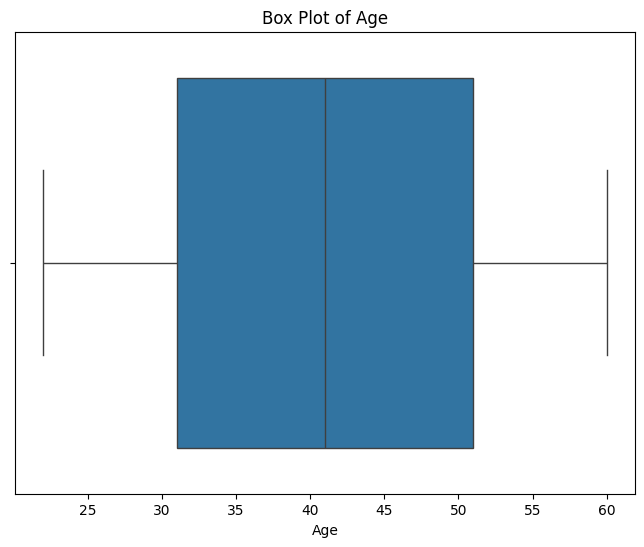

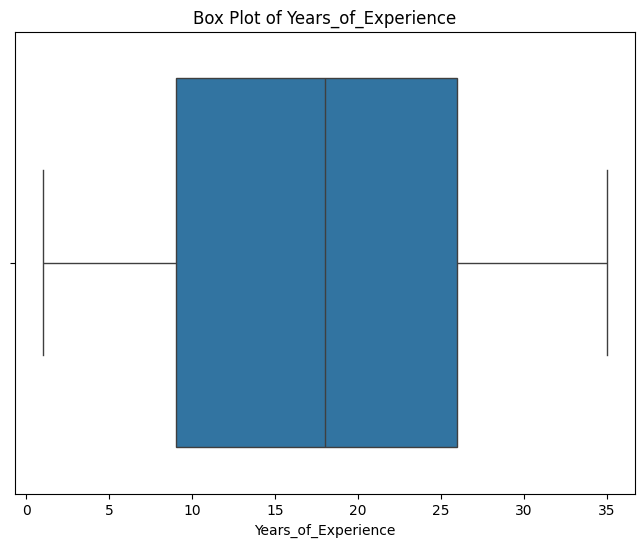

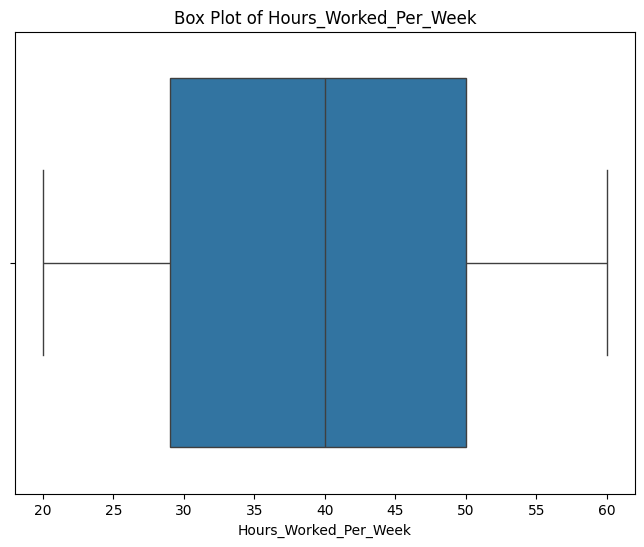

In [50]:
for col in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=unclean_data[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

**Interpretation**

In [51]:
cleaned_data=unclean_data.copy()

## Data Analysis

In [52]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                5000 non-null   int64   
 1   Gender                             5000 non-null   category
 2   Job_Role                           5000 non-null   category
 3   Industry                           5000 non-null   category
 4   Years_of_Experience                5000 non-null   int64   
 5   Work_Location                      5000 non-null   category
 6   Hours_Worked_Per_Week              5000 non-null   int64   
 7   Number_of_Virtual_Meetings         5000 non-null   int64   
 8   Work_Life_Balance_Rating           5000 non-null   int64   
 9   Stress_Level                       5000 non-null   category
 10  Mental_Health_Condition            5000 non-null   category
 11  Access_to_Mental_Health_Resources  5000 non-null   cat

In [53]:
#statistical analysis
cleaned_data.describe()

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.995000,17.810200,39.614600,7.559000,2.984200,2.993800,3.007800
std,11.296021,10.020412,11.860194,4.636121,1.410513,1.394615,1.399046
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,4.000000,2.000000,2.000000,2.000000
50%,41.000000,18.000000,40.000000,8.000000,3.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,12.000000,4.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000,5.000000


**Interpretation**

In [54]:
cleaned_data.groupby("Social_Isolation_Rating")['Hours_Worked_Per_Week'].describe()

,count,mean,std,min,25%,50%,75%,max
Social_Isolation_Rating,,,,,,,,
1,953.0,39.532004,12.100823,20.0,29.0,39.0,50.0,60.0
2,1066.0,39.541276,11.618129,20.0,29.0,40.0,49.0,60.0
3,992.0,40.024194,11.570929,20.0,30.0,40.0,50.0,60.0
4,1037.0,39.759884,12.213165,20.0,29.0,40.0,51.0,60.0
5,952.0,39.194328,11.801150,20.0,29.0,39.0,49.0,60.0


....

In [56]:
cleaned_data.groupby("Work_Life_Balance_Rating")['Years_of_Experience'].describe()

,count,mean,std,min,25%,50%,75%,max
Work_Life_Balance_Rating,,,,,,,,
1,1023.0,17.956989,9.987277,1.0,9.0,18.0,26.5,35.0
2,967.0,17.459152,9.949986,1.0,9.0,17.0,26.0,35.0
3,1053.0,17.980057,9.969754,1.0,9.0,18.0,26.0,35.0
4,980.0,17.748980,10.131225,1.0,9.0,18.0,26.0,35.0
5,977.0,17.882293,10.078354,1.0,9.0,18.0,26.0,35.0


...

In [60]:
cleaned_data.groupby('Industry')['Hours_Worked_Per_Week'].describe()

,count,mean,std,min,25%,50%,75%,max
Industry,,,,,,,,
Consulting,680.0,39.205882,11.873733,20.0,30.00,38.0,50.0,60.0
Education,690.0,39.428986,12.097273,20.0,29.00,40.0,50.0,60.0
Finance,747.0,39.192771,11.547329,20.0,29.00,39.0,48.0,60.0
Healthcare,728.0,40.067308,11.609280,20.0,29.75,40.0,50.0,60.0
IT,746.0,40.017426,11.880997,20.0,30.00,40.0,50.0,60.0
Manufacturing,683.0,40.241581,12.040203,20.0,30.00,40.0,51.0,60.0
Retail,726.0,39.150138,11.986811,20.0,29.00,39.0,49.0,60.0


...

<Axes: >

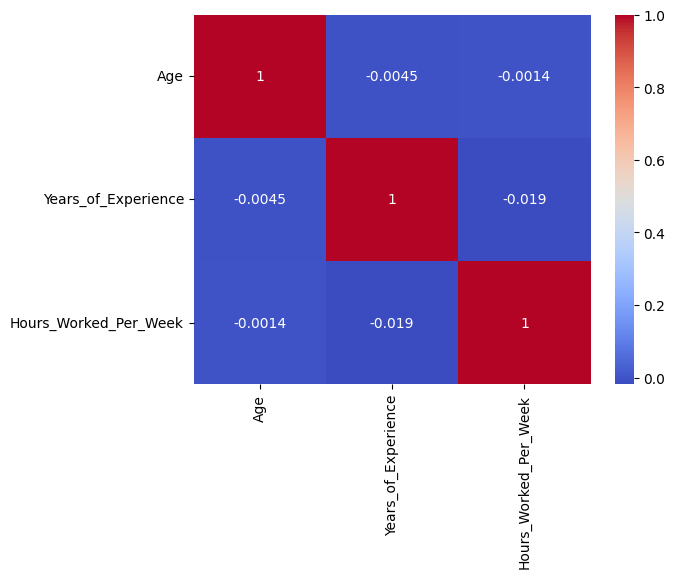

In [59]:
numeric_cols=['Age', 'Years_of_Experience','Hours_Worked_Per_Week']

sns.heatmap(cleaned_data[numeric_cols].corr(), annot=True,cmap="coolwarm")

...

#### Univariate Analysis

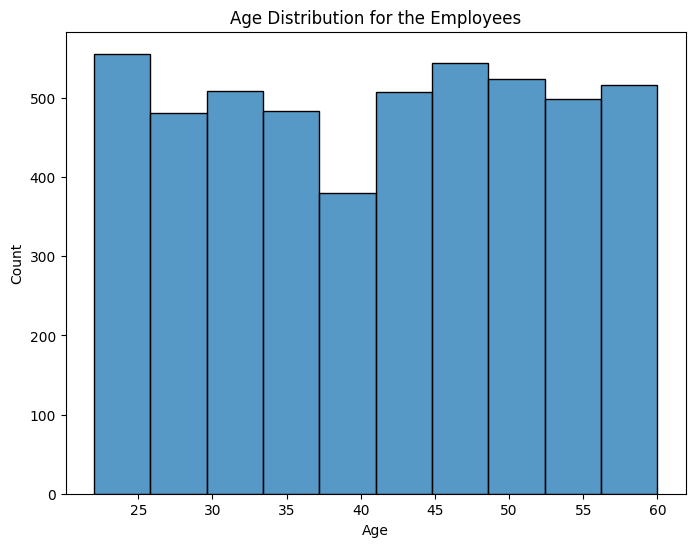

In [64]:
#age distribution of the employees
plt.figure(figsize=(8,6))
sns.histplot(cleaned_data["Age"],bins=10)
plt.title("Age Distribution for the Employees")
plt.show()

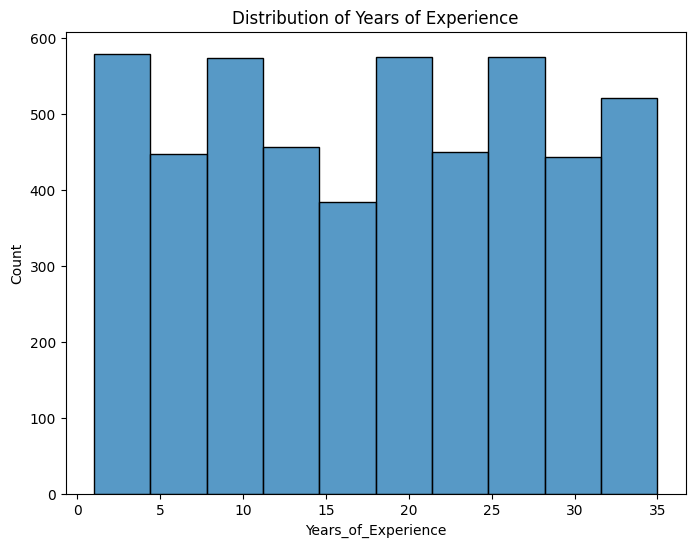

In [65]:
plt.figure(figsize=(8,6))
sns.histplot(cleaned_data["Years_of_Experience"],bins=10)
plt.title("Distribution of Years of Experience")
plt.show()